In [35]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import importlib
import pandas as pd
from datetime import datetime
from tqdm import tqdm
from plotly.subplots import make_subplots
from plotly import tools
import plotly.offline as pyo
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import glob
import math
from scipy import stats
import uproot
from ROOT import TFile, TEfficiency, TH1D, TGraphAsymmErrors, RDataFrame, TCanvas

In [36]:
file = uproot.open('/Users/danielcarber/Documents/ICARUS/purity_mc.root')
print(file.keys())

['events;1', 'events/mc;1', 'events/mc/POT;3', 'events/mc/POT;2', 'events/mc/POT;1', 'events/mc/Livetime;3', 'events/mc/Livetime;2', 'events/mc/Livetime;1', 'events/mc/SelectedNu_Cuts;1', 'events/mc/SelectedCos_PhaseCuts;1', 'events/mc/Efficiency_PhaseCuts;1']


In [37]:
mc_df = file['events/mc/Efficiency_PhaseCuts;1']
mc_df=mc_df.arrays(library='pd')



print(mc_df.keys())
print(mc_df[mc_df['reco_Q']>0])


Index(['all_1eNp_cut', 'category_topology', 'fiducial_cut', 'flash_cut',
       'nu_id', 'reco_Q', 'reco_W', 'reco_alphaT', 'reco_dpT',
       'reco_electron_axial_spread', 'reco_electron_conv_dist',
       'reco_electron_dir_spread', 'reco_electron_energy',
       'reco_electron_pT_mag', 'reco_electron_polar', 'reco_phiT',
       'reco_proton_energy', 'reco_proton_muon_softmax',
       'reco_proton_pion_softmax', 'reco_proton_polar', 'reco_proton_softmax',
       'reco_topology', 'track_containment_cut', 'true_Q', 'true_W',
       'true_alphaT', 'true_dpT', 'true_electron_energy',
       'true_electron_pT_mag', 'true_electron_polar', 'true_phiT',
       'true_proton_energy', 'true_proton_polar', 'true_topology', 'Run',
       'Subrun', 'Evt'],
      dtype='object')
      all_1eNp_cut  category_topology  fiducial_cut  flash_cut  nu_id  \
0              0.0                1.0           1.0        1.0    0.0   
1              1.0                0.0           1.0        1.0    0.0   
2   

In [38]:
quality_cuts = (mc_df['category_topology']==0)|(mc_df['category_topology']==1)
signal = mc_df[quality_cuts]
#mask  = (signal['track_containment_cut']==1)
signal = signal

efficiency = len(signal)/(len(mc_df[quality_cuts]))
print(f"Eff of Containment: {efficiency*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df[quality_cuts])}")

Eff of Containment: 100.00%
Number of Signal and Total: 1492, 1492


In [39]:
def bin_uncertainty(k, N):
    #N is the total number within the bin
    #k is the number of selected in bin
    print(k,":",N)
    #if N >=160:
    #    uncertainty = [0,0]
    #    return uncertainty
    uncertainty = []
    normalize = math.exp(math.lgamma(N+2)-math.lgamma(1)-math.lgamma(N+1))*np.power(1,N)
    #normalize = math.gamma(N+2)/(math.gamma(1)*math.gamma(N+1))*np.power(1,N)
    eff = np.arange(0, 1, 0.0001).tolist()
    a = math.exp(math.lgamma(N+2)-math.lgamma(k+1)-math.lgamma(N-k+1))
    #a = math.gamma(N+2)/(math.gamma(k+1)*math.gamma(N-k+1))
    b = np.power(eff,k)*np.power([1-x for x in eff],N-k)

    #print(gamma(N+2))
    
    prob = b*a
    prob = list(np.divide(prob,normalize))
    #print(sum(prob))
    prob_max_index = prob.index(max(prob))
    prob_max = max(prob)
    if k==0:
        for i in range(int(len(prob)/2)):
            percentage = sum(prob[prob_max_index:prob_max_index+i])/sum(prob)
            if percentage >.68:
                uncertainty= [0,abs(eff[prob_max_index+i]-k/N)]
                break
    elif k==N:
        #print("k=N")
        for i in range(int(len(prob)/2)):
            percentage = sum(prob[prob_max_index-i:prob_max_index])/sum(prob)
            if percentage >.68:
                uncertainty= [abs(eff[prob_max_index-i]-k/N),0]
                break
    else:
        #print("k!=N")
        for i in range(int(prob_max*1000)):
            j=prob_max-(i/1000)
            diff_r = np.array([np.absolute(x - j) for x in prob[prob_max_index:]])
            diff_l = np.array([np.absolute(x - j) for x in prob[:prob_max_index]])
            index_r = diff_r.argmin()
            index_l = diff_l.argmin()
            percentage = sum(prob[index_l:prob_max_index+index_r])/sum(prob)
            if percentage >.68:
                
                uncertainty= [abs(eff[index_l]-k/N),abs(eff[prob_max_index+index_r]-k/N)]
                break
            else:
                uncertainty= [abs(eff[index_l]-k/N),abs(eff[prob_max_index+index_r]-k/N)]
    return uncertainty

In [40]:
def get_eff_bins(df,df_cut,variable ,bins = [0,1000,1]):
    step = 0
    eff_bins,var_bins, unc_bins = [],[],[]
    while step+bins[0] < bins[1]:
        mask = (df[variable] >=bins[0]+step) & (df[variable] <bins[0]+step+bins[2])
        mask_cut = (df_cut[variable] >=bins[0]+step) & (df_cut[variable] <bins[0]+step+bins[2])
        num_bin = sum(mask_cut)
        den_bin = sum(mask)
        uncertainty = bin_uncertainty(num_bin, den_bin)
        if den_bin == 0:
            eff_bins.append(None)
            eff_bins.append(None)
        else:
            eff_bins.append(num_bin/den_bin)
            unc_bins.append(uncertainty)
        var_bins.append(bins[0]+step+(bins[2]/2))
        step += bins[2]
    return eff_bins, var_bins, unc_bins

In [41]:
def cut_eff_bins(df,df_cut,variable ,bins = [0,1000,1]):
    step = 0
    eff_bins,var_bins = [],[]
    while step+bins[0] < bins[1]:
        mask = (df[variable] >=bins[0]+step) & (df[variable] <bins[0]+step+bins[2])
        mask_cut = (df_cut[variable] >=bins[0]+step) & (df_cut[variable] <bins[0]+step+bins[2])
        num_bin = sum(mask_cut)
        den_bin = sum(mask)
        if den_bin == 0:
            eff_bins.append(None)
        else:
            eff_bins.append(num_bin/den_bin)
        var_bins.append(bins[0]+step+(bins[2]/2))
        step += bins[2]
    return eff_bins, var_bins

In [42]:
signal_mask  = (mc_df['category_topology']==0) | (mc_df['category_topology']==1)
signal = mc_df[signal_mask]


mask  = (signal['track_containment_cut']==1)
cut_containment = signal[mask]
mask = (signal['track_containment_cut']==1)&(signal['fiducial_cut']==1)
cut_fiducial = signal[mask]
mask = (signal['track_containment_cut']==1)&(signal['fiducial_cut']==1)&(signal['flash_cut']==1)
cut_flash = signal[mask]
mask  = (signal['all_1eNp_cut']==1)
print(sum(mask))
cut_final_state = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02)

cut_axial = signal[mask] 
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25)
cut_dir = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)
cut_conv = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)&\
        (signal['reco_proton_softmax'] >0.6)
cut_proton = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)&\
        (signal['reco_proton_softmax'] >0.6) & (signal['reco_proton_muon_softmax'] <0.04)
cut_muon = signal[mask]

1168


In [43]:
plt.style.use('styles/muon2024_colorswap.mplstyle')


variable = "true_electron_energy"
bins = [70,3000,150]
eff, var = get_eff_bins(signal,cut_containment,variable,bins = bins)
widths = [bins[2]]*len(eff)
plt.bar(var, eff, width=widths, align='center', edgecolor='black',facecolor='none',label='1. Containment')

eff, var = get_eff_bins(signal,cut_fiducial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='red',facecolor='none',label='2. Fiducial')
eff, var = get_eff_bins(signal,cut_flash,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='orange',facecolor='none',label='3. Flash')
eff, var = get_eff_bins(signal,cut_final_state,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='gold',facecolor='none',label='4. Final State')
eff, var = get_eff_bins(signal,cut_axial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='lime',facecolor='none',label='5. Axial Spread')
eff, var = get_eff_bins(signal,cut_dir,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='green',facecolor='none',label='6. Directional Spread')
eff, var = get_eff_bins(signal,cut_conv,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='cyan',facecolor='none',label='7. Vertex Distance')
eff, var = get_eff_bins(signal,cut_proton,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='blue',facecolor='none',label='8. Proton Softmax')
eff, var = get_eff_bins(signal,cut_muon,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='purple',facecolor='none',label="9. Proton's Muon Softmax")

plt.xlabel("True Electron Energy [MeV]")
plt.ylabel("Efficiency")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
plt.ylim(0, 1.8)
yrange = [0,1.8]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

plt.legend(ncol=2)
#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_energy_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

72 : 72
202 : 205
203 : 203
182 : 185
146 : 147
131 : 132
90 : 90
89 : 90
73 : 73
57 : 57
38 : 38
41 : 41
29 : 29
22 : 22
15 : 16
19 : 19
4 : 4
16 : 16
7 : 7


KeyboardInterrupt: 

In [ ]:
plt.style.use('styles/muon2024_colorswap.mplstyle')


variable = "true_electron_pT_mag"
bins = [0,1000,50]
eff, var = get_eff_bins(signal,cut_containment,variable,bins = bins)
widths = [bins[2]]*len(eff)
print(eff)
plt.bar(var, eff, width=widths, align='center', edgecolor='black',facecolor='none',label='1. Containment')

eff, var = get_eff_bins(signal,cut_fiducial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='red',facecolor='none',label='2. Fiducial')
eff, var = get_eff_bins(signal,cut_flash,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='orange',facecolor='none',label='3. Flash')
eff, var = get_eff_bins(signal,cut_final_state,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='gold',facecolor='none',label='4. Final State')
eff, var = get_eff_bins(signal,cut_axial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='lime',facecolor='none',label='5. Axial Spread')
eff, var = get_eff_bins(signal,cut_dir,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='green',facecolor='none',label='6. Directional Spread')
eff, var = get_eff_bins(signal,cut_conv,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='cyan',facecolor='none',label='7. Vertex Distance')
eff, var = get_eff_bins(signal,cut_proton,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='blue',facecolor='none',label='8. Proton Softmax')
eff, var = get_eff_bins(signal,cut_muon,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='purple',facecolor='none',label="9. Proton's Muon Softmax")

plt.xlabel("True Electron delta PT [MeV/C]")
plt.ylabel("Efficiency")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
plt.ylim(0, 1.8)
yrange = [0,1.8]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

plt.legend(ncol=2)
#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_dpT_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

16 : 25
36 : 67
96 : 133
138 : 187
163 : 212
171 : 240
145 : 181
99 : 129
114 : 147
64 : 78
30 : 44
16 : 23
11 : 15
6 : 8
2 : 3
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


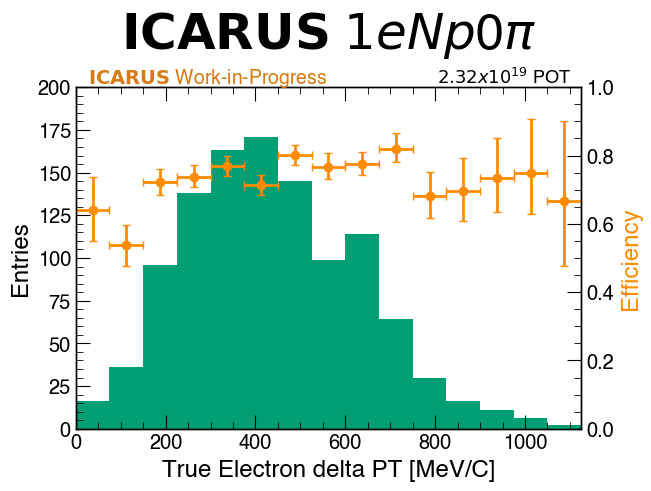

In [51]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_electron_pT_mag"
bins = [0,1125,75]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)


ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var


x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')

ax1.set_xlabel("True Electron delta PT [MeV/C]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

72 : 124
216 : 294
179 : 247
151 : 189
117 : 157
83 : 113
74 : 93
50 : 64
45 : 52
29 : 34
24 : 27
17 : 25
7 : 13
11 : 12
4 : 6
4 : 8
5 : 7
2 : 3
3 : 4
1 : 2
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


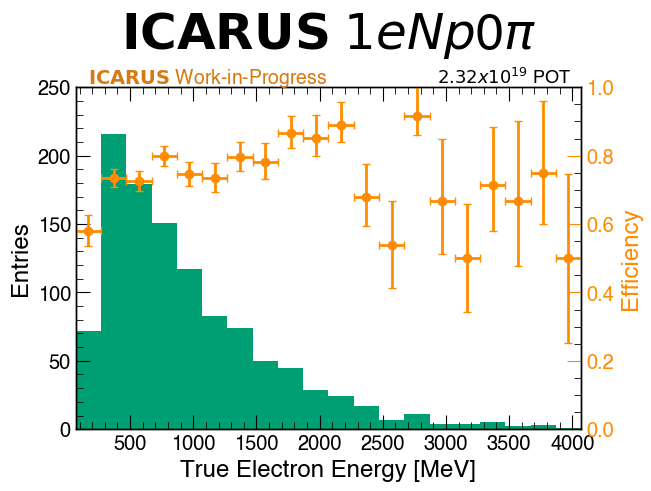

In [67]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_electron_energy"
bins = [70,4070,200]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel("True Electron Energy [MeV]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 250)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

158 : 255
338 : 432
221 : 283
166 : 206
90 : 111
53 : 75
21 : 30
27 : 39
14 : 21
5 : 8
6 : 10
3 : 5
4 : 6
0 : 2
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


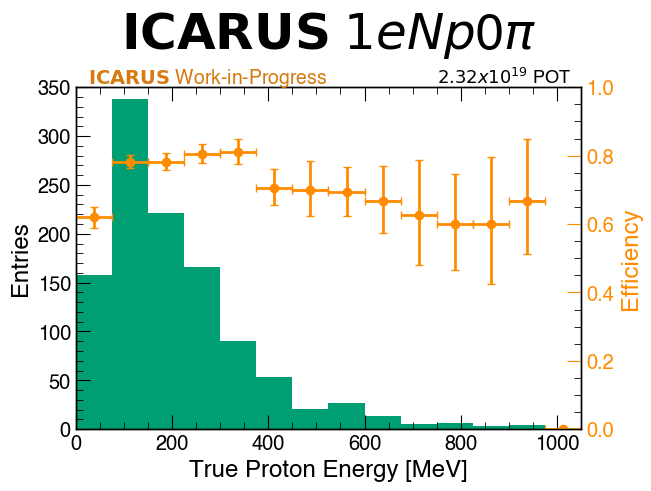

In [68]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_proton_energy"
bins = [0,1050,75]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var

x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel("True Proton Energy [MeV]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 350)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

131 : 187
185 : 244
168 : 233
137 : 173
122 : 162
100 : 129
75 : 89
50 : 67
45 : 62
30 : 40
20 : 31
11 : 20
7 : 10
8 : 10
5 : 13
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


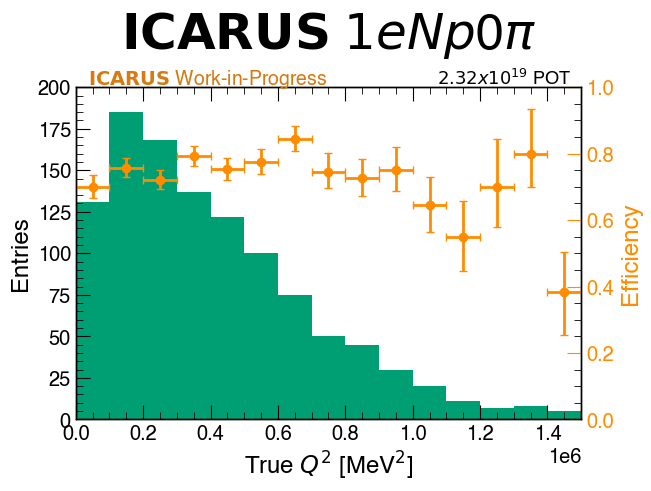

In [69]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_Q"
bins = [0,1.5e6,1e5]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True $Q^2$ [MeV$^2$]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

226 : 331
250 : 325
220 : 273
155 : 198
105 : 146
67 : 96
37 : 44
21 : 30
13 : 17
9 : 15
0 : 4
3 : 4
0 : 4
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


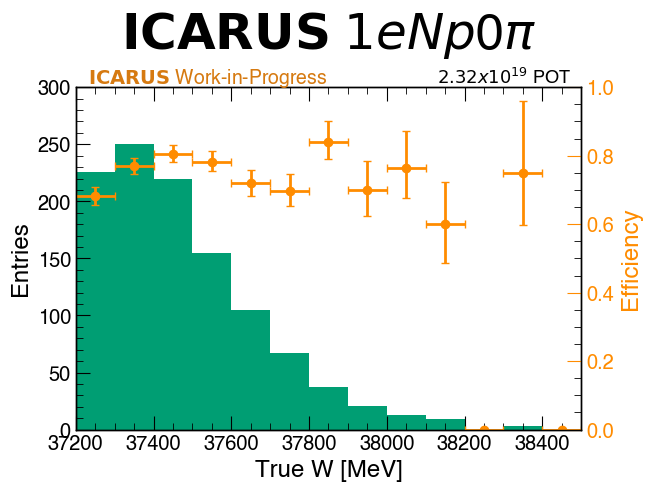

In [55]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_W"
bins = [3.72e4,3.85e4,1e2]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True W [MeV]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 300)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

55 : 76
134 : 175
147 : 182
131 : 186
103 : 138
61 : 84
76 : 105
63 : 90
51 : 71
40 : 60
47 : 61
46 : 65
32 : 44
28 : 32
25 : 32
19 : 23
12 : 18
14 : 17
6 : 8
2 : 5
9 : 10
2 : 3
1 : 1
1 : 1
1 : 2
0 : 1
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


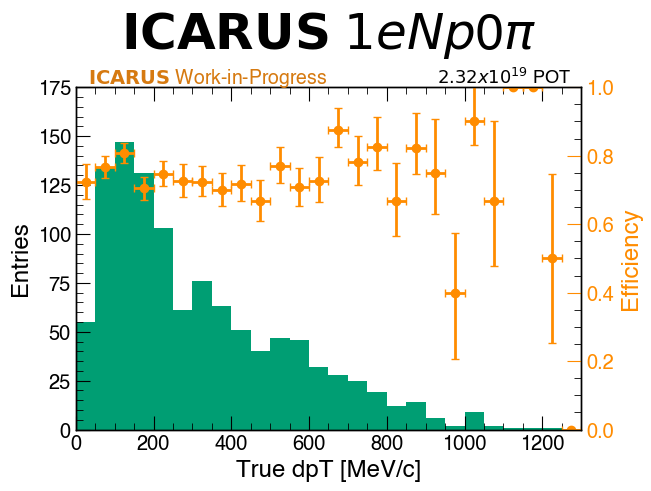

In [62]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_dpT"
bins = [0,1300,50]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True dpT [MeV/c]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 175)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

50 : 84
59 : 80
54 : 67
53 : 78
68 : 81
61 : 88
81 : 106
95 : 116
109 : 145
128 : 175
128 : 165
150 : 202
71 : 105
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


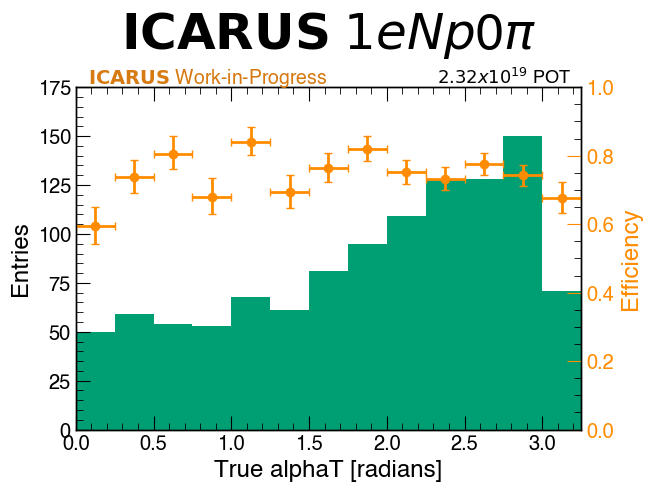

In [57]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_alphaT"
bins = [0,3.25,.25]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True alphaT [radians]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 175)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

436 : 580
220 : 285
116 : 163
71 : 98
70 : 92
49 : 70
34 : 40
27 : 36
21 : 27
17 : 29
21 : 31
20 : 27
5 : 14
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


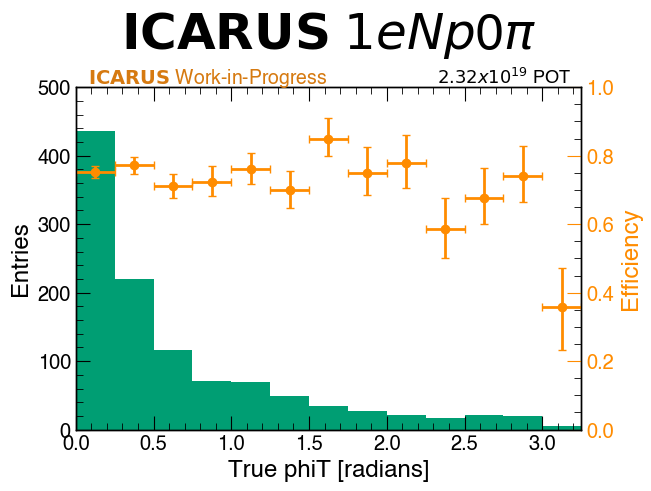

In [58]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_phiT"
bins = [0,3.25,.25]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True phiT [radians]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 500)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

12 : 21
17 : 24
10 : 18
16 : 21
15 : 19
18 : 29
11 : 19
17 : 24
33 : 41
22 : 36
29 : 35
44 : 55
38 : 51
42 : 58
64 : 70
58 : 74
73 : 90
111 : 145
155 : 199
218 : 291
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


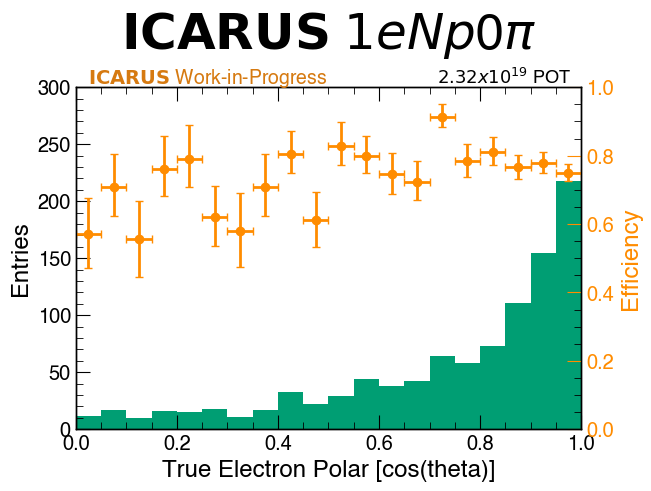

In [59]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_electron_polar"
bins = [0,1.0,.05]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True Electron Polar [cos(theta)]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 300)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

15 : 19
12 : 17
18 : 22
20 : 29
32 : 40
28 : 43
22 : 28
31 : 38
53 : 70
47 : 59
53 : 62
58 : 79
62 : 85
69 : 91
82 : 104
84 : 100
75 : 102
73 : 97
84 : 125
80 : 124
Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


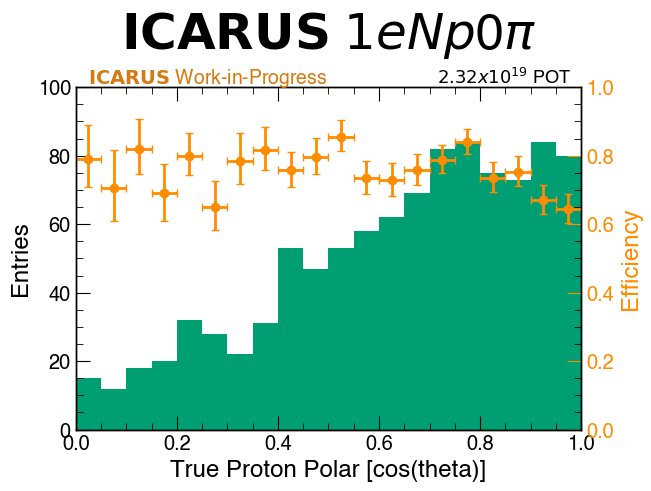

In [60]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_proton_polar"
bins = [0,1.0,.05]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True Proton Polar [cos(theta)]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 100)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

KeyError: 'true_opening_angle'

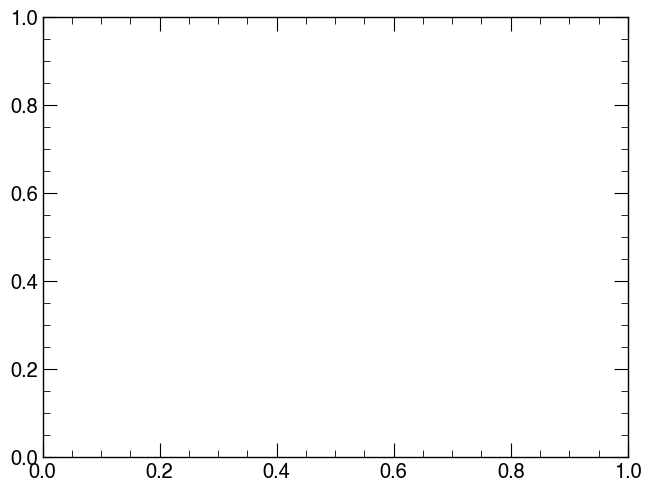

In [63]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_opening_angle"
bins = [0,1.0,.05]

eff, var, unc = get_eff_bins(signal,cut_muon,variable,bins = bins)
low_error = [sublist[1] for sublist in unc]
high_error = [sublist[0] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)

ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')
scatter_y = eff  # Put points slightly above the highest bin
scatter_x = var
x_err = bins[2]/2
ax2 = ax1.twinx()
ax2.errorbar(scatter_x, scatter_y,yerr=y_err,xerr=x_err, capsize=3, color='darkorange',fmt='o', label='Efficiency')
ax2.tick_params(axis='y', colors='darkorange')
ax1.set_xlabel(r"True Proton Polar [cos(theta)]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 100)
ax2.set_ylim(0, 1)
yrange = [0,1]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/True_electron_electron_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")